In [1]:
## Import Libraries
import pandas as pd
import numpy as np

## Visualizations
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.figure_factory as ff
from matplotlib import pyplot as plt
import seaborn as sns

## Cross-Validation using KFold
from numpy import array
from sklearn.model_selection import KFold
from sklearn.metrics import confusion_matrix, classification_report,  accuracy_score
from sklearn.model_selection import cross_validate

## Scalers
from sklearn import preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import PowerTransformer

# Algorithms
from sklearn import model_selection
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
import xgboost as xgb

In [2]:
# Ingest Data
pd.options.display.max_columns = 500
origdata = pd.read_csv('titanictrain.csv')

In [3]:
# Processing Name to strip Title.  Done first since we use Title to group by Age and resolve NANs.
origdata['Title'] = origdata['Name'].str.split('.').str[0].str.split(',').str[1]

# Process NANs
origdata['Age'].fillna(origdata.groupby('Title')['Age'].transform('median'), inplace=True)
origdata['Embarked'].fillna('S', inplace=True) #Majority seems to be S.

# Cabin is more delicate.  After we visualized the importance we come back to adjust for NANs.
origdata['Cabin'].fillna('Z', inplace=True)

## Create a dataset for VIZ & one for ML
df = origdata

# Simplify Title Mapping
TitleMap = {
    ' Mr': 'Mr', ' Mrs':'Mrs', ' Miss':'Miss', ' Master':'Master', ' Don':'Other', ' Rev':'Other', ' Dr':'Other', 
    ' Mme':'Mrs',' Ms':'Miss', ' Major':'Other', ' Lady':'Mrs', ' Sir':'Other', ' Mlle':'Miss', ' Col':'Other',
    ' Capt':'Other',' the Countess':'Mrs', ' Jonkheer':'Other' 
}
df['Title'] = df['Title'].map(TitleMap)

In [4]:
#Process Age with bins.
#Create Bin Labels for Amounts (lowest to highest in funding)
AmtBinLabel = ['Child', 'Teen', 'Graduate', 'Adult', 'Senior']

#Binning Amounts
AmtBins = [0, 12, 19, 35, 65, 100]

df['AgeBin1'] = pd.cut(df['Age'], bins=AmtBins, labels=AmtBinLabel, precision=0)
df.drop(['PassengerId'], axis=1, inplace=True)
df.drop(['Name'], axis=1, inplace=True)
df.drop(['Ticket'], axis=1, inplace=True)
df.drop(['SibSp'], axis=1, inplace=True) #Age + Title is preferred.  
df.drop(['Parch'], axis=1, inplace=True) #Could group by Family size if needed.
df.drop(['Age'], axis=1, inplace=True)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Survived  891 non-null    int64   
 1   Pclass    891 non-null    int64   
 2   Sex       891 non-null    object  
 3   Fare      891 non-null    float64 
 4   Cabin     891 non-null    object  
 5   Embarked  891 non-null    object  
 6   Title     891 non-null    object  
 7   AgeBin1   891 non-null    category
dtypes: category(1), float64(1), int64(2), object(4)
memory usage: 49.9+ KB


In [5]:
# Label Encode in the same column.
le = preprocessing.LabelEncoder()
df['AgeBin1'] = le.fit_transform(df['AgeBin1'])
df['Pclass'] = le.fit_transform(df['Pclass'])
df['Sex'] = le.fit_transform(df['Sex'])
df['Embarked'] = le.fit_transform(df['Embarked'])
df['Title'] = le.fit_transform(df['Title'])

#Strip and Label Encode Cabin in the same column.
df['Cabin'] = df.Cabin.str[0]
df['Cabin'] = le.fit_transform(df['Cabin'])

In [6]:
##  We want to predict the cabin based on all other features. 
cabin = [8]
dfcabinOther = df[~(df.Cabin.isin(cabin))] #Reverse the mask with ~ for not Cabin 8.  

dfcabinY = dfcabinOther.Cabin  #Target is to predict Cabin.
dfcabinOther.drop(['Cabin'], axis=1, inplace=True)  #Drop the dependent variable from training data.

In [7]:
dfcabinOther.drop(['Title'], axis=1, inplace=True)

In [11]:
# Compare multiple models
models = []
models.append(('LR', LogisticRegression()))
models.append(('LDA', LinearDiscriminantAnalysis()))
models.append(('KNN', KNeighborsClassifier()))
models.append(('DTC', DecisionTreeClassifier()))
models.append(('GNB', GaussianNB()))
models.append(('SVM', SVC()))
models.append(('XGB', xgboost()))

# Evaluate each model in turn
results = []
names = []
scoring = 'accuracy'
for name, model in models:
	kfold = model_selection.KFold(n_splits=12, shuffle=True, random_state=10)
	cv_results = model_selection.cross_val_score(model, dfcabinOther, dfcabinY, cv=kfold, scoring=scoring)
	results.append(cv_results)
	names.append(name)
	msg = "%s: %f (%f)" % (name, cv_results.mean(), cv_results.std())
	print(msg)

TypeError: 'module' object is not callable

In [186]:
# Select BEST model.  Then Create cross validation data to Train and Test.  Tune parameters.
foldsize = 12
kf = KFold(n_splits = foldsize, shuffle = True, random_state = 10)
kfolds = kf.split(dfcabinOther)

model = DecisionTreeClassifier(max_depth =8, random_state = 10)
i = 1
for train_index, test_index in kfolds:
    X_train = dfcabinOther.iloc[train_index]
    X_test = dfcabinOther.iloc[test_index]
    y_train = dfcabinY.iloc[train_index]
    y_test = dfcabinY.iloc[test_index]
        
    #Train the model
    model.fit(X_train, y_train)
#     print(f"Accuracy for the fold no. {i} on the test set: {accuracy_score(y_test, model.predict(X_test))}")
#     i += 1
    
dfcabinprediction = model.predict(X_test)
print(classification_report(y_test, dfcabinprediction))
print("F1 Score Accuracy: ",  accuracy_score(y_test, model.predict(X_test))*100)

for i, score in enumerate(cross_validate(model, dfcabinOther,dfcabinY, cv=foldsize)["test_score"]):
    print(f"Accuracy for the fold no. {i} on the test set: {score}")

              precision    recall  f1-score   support

           1       0.50      0.75      0.60         4
           2       0.67      0.57      0.62         7
           3       1.00      0.50      0.67         2
           4       1.00      1.00      1.00         1
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         1

    accuracy                           0.71        17
   macro avg       0.86      0.80      0.81        17
weighted avg       0.75      0.71      0.71        17

F1 Score Accuracy:  70.58823529411765
Accuracy for the fold no. 0 on the test set: 0.35294117647058826
Accuracy for the fold no. 1 on the test set: 0.5294117647058824
Accuracy for the fold no. 2 on the test set: 0.5882352941176471
Accuracy for the fold no. 3 on the test set: 0.7058823529411765
Accuracy for the fold no. 4 on the test set: 0.47058823529411764
Accuracy for the fold no. 5 on the test set: 0.5294117647058824
Accuracy for the fold no. 6 on th

/opt/anaconda3/lib/python3.7/site-packages/sklearn/model_selection/_split.py:667: UserWarning:

The least populated class in y has only 1 members, which is less than n_splits=12.



In [253]:
# Use model to replace Cabin Z with predicted value.
dfcabinZ = df[(df.Cabin.isin(cabin))]

In [254]:
dfcabinZ.drop('Cabin', axis=1, inplace=True)
dfcabinZTitle = dfcabinZ[['Title']]
dfcabinZ.drop('Title', axis=1, inplace=True)

In [255]:
dfcabinZprediction = model.predict(dfcabinZ)

In [256]:
dfcabinZ['Cabin'] = dfcabinZprediction
dfcabinZ['Title'] = dfcabinZTitle
other = df[~(df.Cabin.isin(cabin))]
dfCabinFinal = pd.concat([other, dfcabinZ], axis=0)

In [257]:
dfCabinFinal.Cabin.value_counts()

5    660
1     77
2     68
3     33
4     32
0     16
6      4
7      1
Name: Cabin, dtype: int64

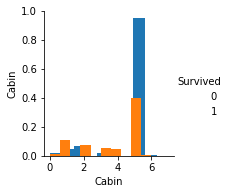

In [258]:
g = sns.PairGrid(dfCabinFinal, vars=['Cabin'], hue="Survived")
g.map_diag(plt.hist)
g.map_offdiag(plt.scatter)
g.add_legend();